# val_04 — Licks the lickometer missed, measured from pose tracking

This notebook responds to
[dynamic-foraging-processing#96](https://github.com/AllenNeuralDynamics/dynamic-foraging-processing/issues/96):
the mouse licks, the video shows it, the lickometer records nothing. It measures how often that
happens in each session and gives a per-session QC table.

Two event streams are compared. A lickometer event is a contact detection. A pose excursion is
a run of frames in which Lightning Pose places `tongue_tip_center` within 10 px of a spout on the
bottom camera. Pose tracking is itself noisy, so an excursion with no lickometer event is only a
candidate for a missed lick until it is shown to look like a real contact. The definitions used
throughout:

- A confirmed contact is an excursion with a lickometer event within 100 ms of its closest
  approach.
- An excursion is contact-like when it comes at least as close to the spout as that
  session's median confirmed contact and stays within 10 px for at least as many frames as the
  25th percentile of confirmed contacts, and no longer than twice their 95th percentile. The
  reference is taken per session, so camera geometry and pixel scale drop out.
- A candidate missed lick is a contact-like excursion with no lickometer event within
  100 ms, at a time when the lickometer was active, meaning it recorded an event within 60 s on
  both sides.
- The miss rate of a session is candidates / (candidates + confirmed contacts).

Candidates are further sorted by what the lickometer was doing around them: inside a bout
(lickometer events within 2.5 inter-lick intervals on both sides, a skipped beat), in a silent
bout (three or more candidates within half a second and no lickometer events), at the edge of a
bout, or isolated.

The dataset is 53 sessions from 17 subjects, 2024-05-31 to 2025-07-03. The session named in the
issue, `behavior_856239_2026-07-24_12-50-23`, has no pose output yet. The analyses behind each
choice above are in `val_05_lickometer_qc_methods.ipynb`.

1. Setup and event tables
2. What a confirmed contact looks like in pose
3. From raw disagreement to candidates
4. Miss rate per session
5. Day-to-day range within a subject
6. QC table
7. What this can and cannot tell you
8. Clips for review

## 1. Setup and event tables

In [1]:
%matplotlib inline
from pathlib import Path
import glob
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import lickometer_qc as lq
from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [2]:
if Path("/root/capsule").exists():
    ENV     = "codeocean"
    SCRATCH = Path("/root/capsule/scratch")
    DATA    = Path("/root/capsule/data")
    EVENTS_DIR = SCRATCH / "figures" / "val_04_lickometer_qc"
else:
    ENV     = "local"
    SCRATCH = Path("/Users/mib/Documents/Code/kinematics_analysis/data")
    DATA    = SCRATCH
    EVENTS_DIR = SCRATCH / "for_local"

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "val_04_lickometer_qc"
SAVE_FIG = False
SESSION_DIR = SCRATCH / "session_analysis_mlk"
REBUILD  = False    # True forces the event tables to be rebuilt from the intermediates (Code Ocean)

# Event detection.
D0            = 10     # px; an excursion is a run of frames within D0 of a spout
CONF          = 0.8    # keypoint confidence floor
T_REFRACTORY  = 0.1    # s; one event per stream per 100 ms
MATCH_WINDOW  = 0.1    # s; a lickometer event this close to the closest approach confirms it
ACTIVE_WINDOW = 60.0   # s; the lickometer counts as active with an event within this on both sides

# Contact-like, relative to the session's confirmed contacts.
DEPTH_Q          = 0.50   # reaches at least the median confirmed closest approach
DWELL_Q          = 0.25   # dwells at least the 25th percentile of confirmed contacts
DWELL_MAX_FACTOR = 2.0    # and no longer than twice their 95th percentile

# Gates and flags for the QC table.
MIN_CONTACT       = 200    # contact-like excursions needed before a session is scored
MIN_LICK_COVERAGE = 0.90   # fraction of lickometer events with a tracked tongue nearby (Code Ocean)
MAX_OFFSET_MS     = 50.0   # |median stream offset| above this means the clocks disagree
FLAG_MISS         = 0.05   # flag a session when the Wilson lower bound clears this
FLAG_SPREAD       = 0.05   # flag a subject when its day-to-day range clears this

C_CAND  = PALETTE["pos"]       # candidate missed licks
C_CONF  = PALETTE["neg"]       # confirmed contacts
C_GATED = PALETTE["not_sig"]
CONTEXT_COLORS = {"in_bout": PALETTE["pos"], "silent_bout": PALETTE["accent"],
                  "bout_edge": PALETTE["sig"], "isolated": PALETTE["not_sig"]}
CONTEXT_LABELS = {"in_bout": "in a bout (skipped beat)", "silent_bout": "silent bout",
                  "bout_edge": "edge of a bout", "isolated": "isolated"}
print("ENV={}".format(ENV))

ENV=local


The event tables are built once from the per-session intermediates on Code Ocean and written to
`EVENTS_DIR` as `val_04_pose_events.parquet`, `val_04_lickometer_events.parquet` and
`val_04_sessions.parquet`. Anywhere else they are read from there.

In [3]:
POSE_COLS = ["t_onset", "t_min", "d_min", "n_frames", "span_s", "session"]
paths = {name: EVENTS_DIR / "val_04_{}.parquet".format(name)
         for name in ["pose_events", "lickometer_events", "sessions"]}

if paths["pose_events"].exists() and paths["lickometer_events"].exists() and not REBUILD:
    pose = pd.read_parquet(paths["pose_events"])[POSE_COLS]
    licko = pd.read_parquet(paths["lickometer_events"])[["session", "t"]]
    sessions = pd.read_parquet(paths["sessions"]) if paths["sessions"].exists() else None
    print("read event tables from {}".format(EVENTS_DIR))
elif IS_CO:
    session_dirs = sorted(glob.glob(str(SESSION_DIR / "*")))
    with contextlib.redirect_stdout(io.StringIO()) as buf:
        pose, licko, sessions = lq.build_event_tables(session_dirs, d=D0, conf=CONF,
                                                      coverage_halfwidth=MATCH_WINDOW)
    print(buf.getvalue()[-3000:])
    EVENTS_DIR.mkdir(parents=True, exist_ok=True)
    pose.to_parquet(paths["pose_events"], index=False)
    licko.to_parquet(paths["lickometer_events"], index=False)
    sessions.to_parquet(paths["sessions"], index=False)
    print("wrote event tables to {}".format(EVENTS_DIR))
else:
    raise FileNotFoundError("No event tables in {} and not on Code Ocean.".format(EVENTS_DIR))

if sessions is None:
    print("no val_04_sessions.parquet: lick_coverage and trial bounds are unavailable, "
          "the coverage gate is skipped and the lickometer's first and last event bound each session.")

print("{:,} excursions and {:,} lickometer events over {} sessions, {} subjects.".format(
    len(pose), len(licko), pose["session"].nunique(),
    pose["session"].str.split("_").str[1].nunique()))

read event tables from /Users/mib/Documents/Code/kinematics_analysis/data/for_local
no val_04_sessions.parquet: lick_coverage and trial bounds are unavailable, the coverage gate is skipped and the lickometer's first and last event bound each session.


101,824 excursions and 203,762 lickometer events over 53 sessions, 17 subjects.


In [4]:
# Score every excursion against its session's lickometer stream, calibrate contact-like per
# session, label candidates and their context, and reduce to one row per session.
annot = lq.annotate_pose_events(pose, licko, t_refractory=T_REFRACTORY,
                                match_window=MATCH_WINDOW, active_window=ACTIVE_WINDOW)
ref = lq.contact_reference(annot, depth_quantile=DEPTH_Q, dwell_quantile=DWELL_Q,
                           dwell_max_factor=DWELL_MAX_FACTOR)
events = lq.classify_events(annot, ref)

lk_kept = {s: (lambda t: t[lq.refractory_mask(t, T_REFRACTORY)])(np.sort(g["t"].to_numpy()))
           for s, g in licko.groupby("session")}
rhythm = {s: lq.lickometer_rhythm(t) for s, t in lk_kept.items()}
events["context"] = lq.candidate_context(events, rhythm)

summary = lq.summarize_sessions(events, licko, ref, t_refractory=T_REFRACTORY,
                                match_window=MATCH_WINDOW, sessions=sessions)
kept = events[events["kept"]]
print("kept excursions {:,}; contact-like in active stretches {:,}; confirmed {:,}; candidates {:,}".format(
    len(kept), int(summary["n_contact"].sum()), int(summary["n_confirmed"].sum()),
    int(summary["n_candidate"].sum())))

kept excursions 80,181; contact-like in active stretches 37,547; confirmed 36,951; candidates 596


## 2. What a confirmed contact looks like in pose

The lickometer's own detections describe what a contact looks like in the pose stream of that
session: how close `tongue_tip_center` gets to the spout keypoint and how many frames it stays
within 10 px. Excursions without a lickometer event are compared against that. The figure shows
one session; the table gives the range of the reference values across all sessions.

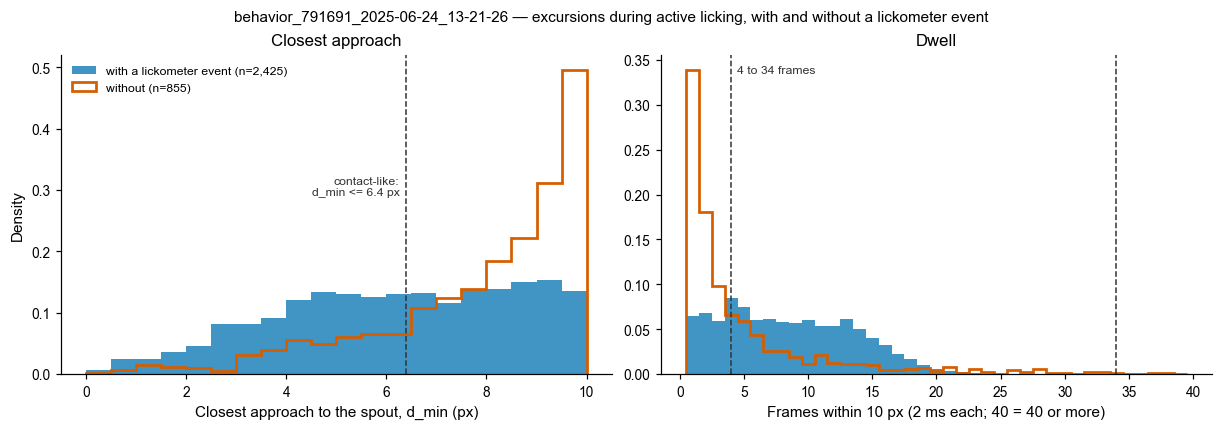

Reference values across 53 sessions:


,d_ref,frames_lo,frames_hi,n_confirmed_all
min,3.9,2.0,22.0,97.0
25%,5.0,3.0,34.3,707.0
50%,6.7,4.0,44.0,1052.0
75%,7.5,7.0,50.0,2012.0
max,8.8,10.0,86.0,3443.0


In [5]:
EXAMPLE = "behavior_791691_2025-06-24_13-21-26"
if EXAMPLE not in set(events["session"]):
    EXAMPLE = summary.index[0]

ex = kept[(kept["session"] == EXAMPLE) & kept["lk_active"]]
conf_ex, unconf_ex = ex[ex["has_lk"]], ex[~ex["has_lk"]]
r = ref.loc[EXAMPLE]

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
bins_d = np.arange(0, D0 + 0.5, 0.5)
axs[0].hist(conf_ex["d_min"], bins=bins_d, density=True, color=C_CONF, alpha=0.75,
            label="with a lickometer event (n={:,})".format(len(conf_ex)))
axs[0].hist(unconf_ex["d_min"], bins=bins_d, density=True, histtype="step", lw=1.8, color=C_CAND,
            label="without (n={:,})".format(len(unconf_ex)))
axs[0].axvline(r["d_ref"], color=PALETTE["all"], ls="--", lw=1)
axs[0].annotate("contact-like:\nd_min <= {:.1f} px".format(r["d_ref"]), xy=(r["d_ref"], 0.62),
                xycoords=("data", "axes fraction"), xytext=(-4, 0), textcoords="offset points",
                ha="right", va="top", fontsize=8, color=PALETTE["all"])
axs[0].set_xlabel("Closest approach to the spout, d_min (px)")
axs[0].set_ylabel("Density")
axs[0].set_title("Closest approach")
axs[0].legend(fontsize=8, loc="upper left")

bins_f = np.arange(0.5, 40.5, 1)
axs[1].hist(conf_ex["n_frames"].clip(upper=40), bins=bins_f, density=True, color=C_CONF, alpha=0.75)
axs[1].hist(unconf_ex["n_frames"].clip(upper=40), bins=bins_f, density=True, histtype="step",
            lw=1.8, color=C_CAND)
axs[1].axvline(r["frames_lo"], color=PALETTE["all"], ls="--", lw=1)
axs[1].axvline(r["frames_hi"], color=PALETTE["all"], ls="--", lw=1)
axs[1].annotate("{:.0f} to {:.0f} frames".format(r["frames_lo"], r["frames_hi"]),
                xy=(r["frames_lo"], 1.0), xycoords=("data", "axes fraction"), xytext=(4, -12),
                textcoords="offset points", fontsize=8, color=PALETTE["all"])
axs[1].set_xlabel("Frames within {} px (2 ms each; 40 = 40 or more)".format(D0))
axs[1].set_title("Dwell")
for ax in axs:
    style_ax(ax)
fig.suptitle("{} — excursions during active licking, with and without a lickometer event".format(
    EXAMPLE), fontsize=10)
save_fig(fig, "fig1_contact_reference", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Reference values across {} sessions:".format(len(ref)))
display(ref.describe().loc[["min", "25%", "50%", "75%", "max"]].round(1))

### Reading the output

In this session a confirmed contact brings the keypoint a median of 6.4 px from the spout and
keeps it within 10 px for a median of 8 frames (16 ms). Excursions with no lickometer event pile
up at the threshold, 8 to 10 px, and most last one to three frames. Contact-like excludes those.

The reference differs a lot between sessions: the median confirmed approach runs from 3.9 to
8.8 px and the dwell floor from 2 to 10 frames. A fixed pixel threshold would score the same
tongue movement differently from one rig setup to the next, which is why the reference is per
session.

## 3. From raw disagreement to candidates

Counting every pose excursion with no lickometer event as a miss gives a very different number
from counting candidates. This table follows the excursions of one session through each step.

In [6]:
def waterfall(events, session):
    g = events[events["session"] == session]
    k = g[g["kept"]]
    a = k[k["lk_active"]]
    c = a[a["contact"]]
    rows = [
        ("excursions within {} px".format(D0), len(g), int((~g["has_lk"]).sum())),
        ("after the {:.0f} ms refractory filter".format(1000 * T_REFRACTORY), len(k), int((~k["has_lk"]).sum())),
        ("while the lickometer was active (event within {:.0f} s both sides)".format(ACTIVE_WINDOW),
         len(a), int((~a["has_lk"]).sum())),
        ("contact-like (d_min <= {:.1f} px, {:.0f} to {:.0f} frames)".format(
            ref.loc[session, "d_ref"], ref.loc[session, "frames_lo"], ref.loc[session, "frames_hi"]),
         len(c), int((~c["has_lk"]).sum())),
    ]
    out = pd.DataFrame(rows, columns=["step", "excursions", "no lickometer event within 100 ms"])
    out["fraction"] = out["no lickometer event within 100 ms"] / out["excursions"]
    return out

print(EXAMPLE)
display(waterfall(events, EXAMPLE).round(3))

pooled = 1.0 - kept.groupby("session")["has_lk"].mean()
print("Across sessions, the fraction of kept excursions with no lickometer event has a median of "
      "{:.1%} (range {:.1%} to {:.1%}); the candidate miss rate has a median of {:.1%} "
      "(range {:.1%} to {:.1%}).".format(pooled.median(), pooled.min(), pooled.max(),
                                         summary["miss_rate"].median(),
                                         summary["miss_rate"].min(), summary["miss_rate"].max()))

behavior_791691_2025-06-24_13-21-26


,step,excursions,no lickometer event within 100 ms,fraction
0,excursions within 10 px,5848,2751,0.470
1,after the 100 ms refractory filter,3928,1498,0.381
2,while the lickometer was active (event within ...,3280,855,0.261
3,"contact-like (d_min <= 6.4 px, 4 to 34 frames)",1320,122,0.092


Across sessions, the fraction of kept excursions with no lickometer event has a median of 2.5% (range 0.0% to 38.1%); the candidate miss rate has a median of 0.8% (range 0.0% to 32.9%).


### Reading the output

Of this session's 3,928 excursions after the refractory filter, 1,498 (38%) have no lickometer
event within 100 ms. Restricting to the time the lickometer was active removes 648 excursions,
643 of them without a lickometer event: the 380 recorded before the first lickometer event, and
263 from stretches with no lickometer event for over a minute, mostly the final half hour when
the animal had largely stopped. Of the 3,280 that remain, 855 have no lickometer event, and 122
of those are contact-like. The other 733 are shallower or briefer than this session's confirmed
contacts. The miss rate is 122 / (122 + 1,198) = 9.2%.

## 4. Miss rate per session

One number per session with a 95% Wilson interval, ranked. Sessions with fewer than 200
contact-like excursions, or with a stream offset over 50 ms, are shown in grey and not flagged.
The right panel splits each session's candidates by lickometer context.

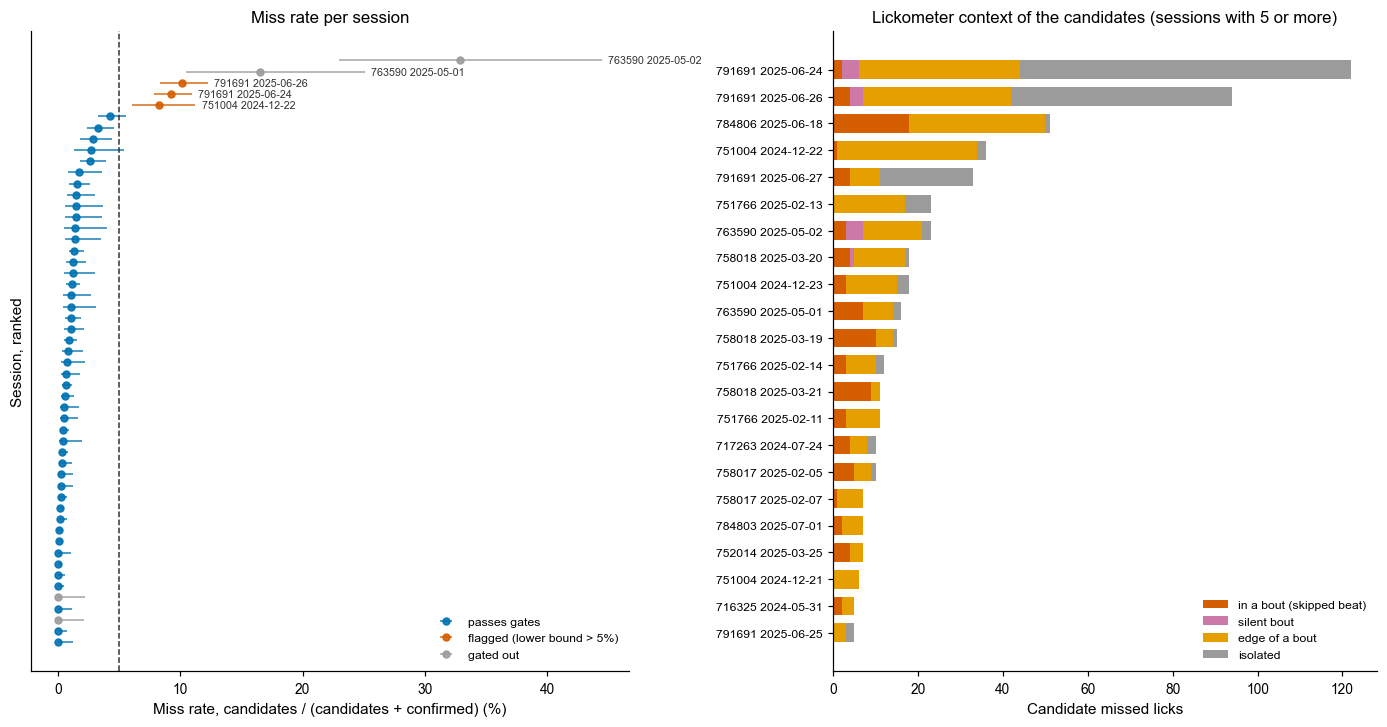

Sessions above the flag line, passing the gates or not:


,subject,n_lickometer,n_contact,n_confirmed,n_candidate,miss_rate,miss_lo,miss_hi,n_in_bout,n_silent_bout,n_bout_edge,n_isolated,offset_median_ms,gate_pass,flag_session
session,,,,,,,,,,,,,,,
behavior_763590_2025-05-02_11-07-07,763590,2401,70,47,23,0.329,0.230,0.445,3,4,14,2,-26.272,False,False
behavior_763590_2025-05-01_10-59-16,763590,1903,97,81,16,0.165,0.104,0.251,7,0,7,2,-66.432,False,False
behavior_791691_2025-06-26_13-39-22,791691,4514,930,836,94,0.101,0.083,0.122,4,3,35,52,-18.304,True,True
behavior_791691_2025-06-24_13-21-26,791691,3847,1320,1198,122,0.092,0.078,0.109,2,4,38,78,-22.368,True,True
behavior_751004_2024-12-22_13-09-11,751004,7126,436,400,36,0.083,0.060,0.112,1,0,33,2,-13.872,True,True


In [7]:
summary["gate_n"] = summary["n_contact"] >= MIN_CONTACT
summary["gate_align"] = summary["offset_median_ms"].abs() <= MAX_OFFSET_MS
if "lick_coverage" in summary.columns:
    summary["gate_coverage"] = summary["lick_coverage"] >= MIN_LICK_COVERAGE
else:
    summary["gate_coverage"] = True
summary["gate_pass"] = summary["gate_n"] & summary["gate_align"] & summary["gate_coverage"]
summary["flag_session"] = summary["gate_pass"] & (summary["miss_lo"] > FLAG_MISS)
summary = summary.sort_values("miss_rate", ascending=False)

fig, axs = plt.subplots(1, 2, figsize=(12.5, 6.5), layout="constrained",
                        gridspec_kw={"width_ratios": [1.1, 1]})

# -- panel 1: ranked miss rate with intervals --
y = np.arange(len(summary))
for mask, col, lbl in [(summary["gate_pass"] & ~summary["flag_session"], C_CONF, "passes gates"),
                       (summary["flag_session"], C_CAND, "flagged (lower bound > {:.0%})".format(FLAG_MISS)),
                       (~summary["gate_pass"], C_GATED, "gated out")]:
    sub = summary[mask]
    if len(sub):
        axs[0].errorbar(100 * sub["miss_rate"], y[mask.to_numpy()],
                        xerr=[100 * (sub["miss_rate"] - sub["miss_lo"]).clip(lower=0),
                              100 * (sub["miss_hi"] - sub["miss_rate"]).clip(lower=0)],
                        fmt="o", ms=4.5, lw=1, color=col, ecolor=col, alpha=0.9, label=lbl)
axs[0].axvline(100 * FLAG_MISS, color=PALETTE["all"], ls="--", lw=1)
for i, (sess, row) in enumerate(summary.iterrows()):
    if row["flag_session"] or (not row["gate_pass"] and row["miss_rate"] > FLAG_MISS):
        axs[0].annotate("{} {}".format(sess.split("_")[1], sess.split("_")[2]),
                        xy=(100 * row["miss_hi"], i), xytext=(4, 0), textcoords="offset points",
                        va="center", fontsize=7, color=PALETTE["all"])
axs[0].invert_yaxis()
axs[0].set_yticks([])
axs[0].set_xlabel("Miss rate, candidates / (candidates + confirmed) (%)")
axs[0].set_ylabel("Session, ranked")
axs[0].set_title("Miss rate per session")
axs[0].legend(fontsize=8, loc="lower right")
style_ax(axs[0])

# -- panel 2: candidate context for sessions with enough candidates to split --
ctx_cols = ["in_bout", "silent_bout", "bout_edge", "isolated"]
top = summary[summary["n_candidate"] >= 5].sort_values("n_candidate", ascending=True)
left = np.zeros(len(top))
for c in ctx_cols:
    vals = top["n_" + c].to_numpy()
    axs[1].barh(np.arange(len(top)), vals, left=left, color=CONTEXT_COLORS[c],
                label=CONTEXT_LABELS[c], height=0.7)
    left += vals
axs[1].set_yticks(np.arange(len(top)))
axs[1].set_yticklabels(["{} {}".format(s.split("_")[1], s.split("_")[2]) for s in top.index],
                       fontsize=8)
axs[1].set_xlabel("Candidate missed licks")
axs[1].set_title("Lickometer context of the candidates (sessions with 5 or more)")
axs[1].legend(fontsize=8, loc="lower right")
style_ax(axs[1])

save_fig(fig, "fig2_miss_rate_by_session", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

show_cols = ["subject", "n_lickometer", "n_contact", "n_confirmed", "n_candidate", "miss_rate",
             "miss_lo", "miss_hi", "n_in_bout", "n_silent_bout", "n_bout_edge", "n_isolated",
             "offset_median_ms", "gate_pass", "flag_session"]
print("Sessions above the flag line, passing the gates or not:")
display(summary.loc[summary["miss_lo"] > FLAG_MISS, show_cols].round(3))

### Reading the output

The median session has a miss rate of 0.8%. Three sessions clear the gates with a lower bound
above 5%: `791691` on 2025-06-26 (10.1%) and 2025-06-24 (9.2%), and `751004` on 2024-12-22
(8.3%). Most of `791691`'s candidates are isolated, a single contact-like excursion with no
lickometer event within a second on either side, or sit at the edge of a bout; the 06-26 session
also holds the set's one dropout minute, with repeated contact-like excursions and no lickometer
event. `751004`'s candidates sit at the edges of bouts, 33 of 36.

`763590` scores 33% and 16% but has 70 and 97 contact-like excursions, and its 2025-05-01
session has a stream offset of −66 ms against −10 to −30 ms everywhere else, so neither day is
scored. `784806` on 2025-06-18 has a 4.2% rate with 18 of its 51 candidates inside bouts, the
largest skipped-beat count in the set; its lower bound is 3.2%, below the flag.

Skipped beats inside a bout, the pattern the issue describes, are rare: 112 of the 596
candidates across all sessions. The median session has 0.3 of them per 1,000 lickometer licks,
and `784806` on 2025-06-18 has the most at 5.6.

## 5. Day-to-day range within a subject

The same miss rate grouped by subject. Consecutive days in the same animal share the camera,
the spouts and most of the behaviour, so a large day-to-day range points at the rig.

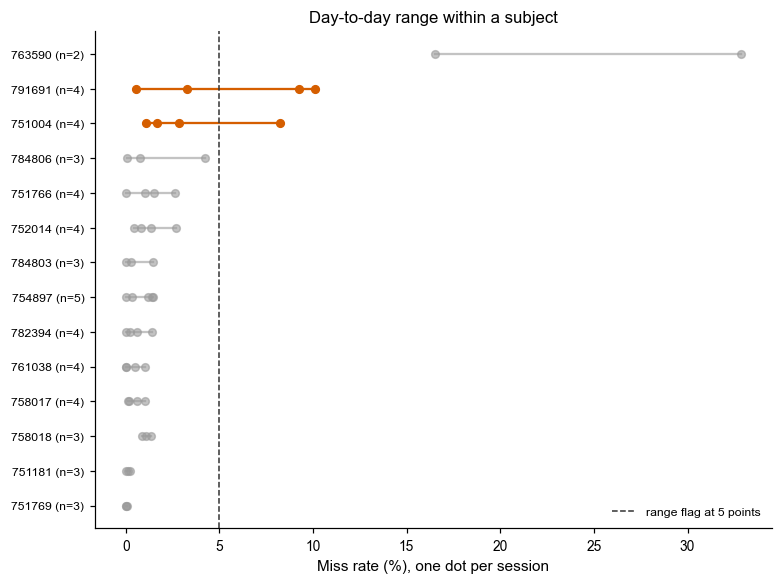

,lo,hi,median,spread,n_sessions
subject,,,,,
763590,16.5,32.9,24.7,16.4,2
791691,0.5,10.1,6.2,9.6,4
751004,1.1,8.3,2.2,7.2,4
784806,0.1,4.2,0.8,4.2,3
751766,0.0,2.6,1.3,2.6,4
752014,0.4,2.7,1.1,2.2,4
784803,0.0,1.5,0.3,1.5,3
754897,0.0,1.4,1.2,1.4,5
782394,0.0,1.4,0.4,1.4,4


Subjects with three or more sessions and a range above 5 points: 791691, 751004


In [8]:
by_subject = (summary.groupby("subject")
              .agg(n_sessions=("miss_rate", "size"), lo=("miss_rate", "min"),
                   hi=("miss_rate", "max"), median=("miss_rate", "median"))
              .assign(spread=lambda t: t["hi"] - t["lo"])
              .sort_values("spread", ascending=False))
multi = by_subject[by_subject["n_sessions"] >= 2]
flagged_subjects = multi[(multi["n_sessions"] >= 3) & (multi["spread"] > FLAG_SPREAD)]

fig, ax = plt.subplots(figsize=(7, 5.2), layout="constrained")
for i, (subject, row) in enumerate(multi.iterrows()):
    hot = subject in flagged_subjects.index
    col = C_CAND if hot else C_GATED
    ax.plot([100 * row["lo"], 100 * row["hi"]], [i, i], "-", color=col, lw=1.5,
            alpha=1.0 if hot else 0.6)
    pts = summary.loc[summary["subject"] == subject, "miss_rate"]
    ax.plot(100 * pts, np.full(len(pts), i), "o", ms=5, color=col, alpha=1.0 if hot else 0.6)
ax.axvline(100 * FLAG_SPREAD, color=PALETTE["all"], ls="--", lw=1,
           label="range flag at {:.0f} points".format(100 * FLAG_SPREAD))
ax.set_yticks(np.arange(len(multi)))
ax.set_yticklabels(["{} (n={})".format(s, int(r["n_sessions"])) for s, r in multi.iterrows()],
                   fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Miss rate (%), one dot per session")
ax.set_title("Day-to-day range within a subject")
ax.legend(fontsize=8, loc="lower right")
style_ax(ax)
save_fig(fig, "fig3_within_subject_range", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

display((100 * multi[["lo", "hi", "median", "spread"]]).round(1).assign(n_sessions=multi["n_sessions"]))
print("Subjects with three or more sessions and a range above {:.0f} points: {}".format(
    100 * FLAG_SPREAD, ", ".join(flagged_subjects.index) if len(flagged_subjects) else "none"))

### Reading the output

`791691` runs 9.2%, 0.5%, 10.1% and 3.3% on four consecutive days, a range of 9.6 points.
`751004` runs 1.1%, 1.7%, 8.3% and 2.8%, a range of 7.2. No other subject with three or more
sessions has a range above 4.2 points. Both animals with a large range are the ones flagged in §4, and in both the high
days are separated by a low one, which is the pattern of an intermittent fault.

## 6. QC table

One row per session. The gates say whether the session can be scored; the flags say whether it
should be looked at.

```
gates   n_contact >= 200
        |offset_median_ms| <= 50
        lick_coverage >= 0.90            (when val_04_sessions.parquet is present)
flags   flag_session   Wilson lower bound of miss_rate > 0.05
        flag_subject   >= 3 sessions and day-to-day range of miss_rate > 0.05
        flag_dropout   any minute with >= 10 contact-like excursions and no lickometer event
```

In [9]:
qc = summary.copy()
qc["flag_subject"] = qc["subject"].map(
    lambda s: s in flagged_subjects.index)
qc["subject_spread"] = qc["subject"].map(by_subject["spread"])
qc["flag_dropout"] = qc["dropout_minutes"].fillna(0) > 0
qc["flag_any"] = qc["flag_session"] | qc["flag_subject"] | qc["flag_dropout"]

out_cols = ["subject", "n_lickometer", "ili_mode_ms", "n_excursions", "raw_disagreement",
            "d_ref", "frames_lo", "frames_hi", "n_contact", "n_confirmed", "n_candidate",
            "miss_rate", "miss_lo", "miss_hi", "candidates_per_1000_licks",
            "n_in_bout", "n_silent_bout", "n_bout_edge", "n_isolated",
            "skipped_beat_frac", "single_interval_frac",
            "offset_median_ms", "offset_iqr_ms", "dropout_minutes",
            "gate_n", "gate_align", "gate_coverage", "gate_pass",
            "flag_session", "flag_subject", "subject_spread", "flag_dropout", "flag_any"]
out_cols += [c for c in ["lick_coverage", "tracked_frac", "trial_start", "trial_end", "duration_s"]
             if c in qc.columns]
qc_table = qc[out_cols]

FIG_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIG_DIR / "val_04_lickometer_qc.csv"
qc_table.to_csv(out_path)
print("wrote {}  ({} sessions)".format(out_path, len(qc_table)))
print("  gates passed:   {}".format(int(qc_table["gate_pass"].sum())))
print("  flag_session:   {}".format(int(qc_table["flag_session"].sum())))
print("  flag_subject:   {} sessions in {} subjects".format(
    int(qc_table["flag_subject"].sum()), qc_table.loc[qc_table["flag_subject"], "subject"].nunique()))
print("  flag_dropout:   {}".format(int(qc_table["flag_dropout"].sum())))
display(qc_table.loc[qc_table["flag_any"],
                     ["miss_rate", "miss_lo", "n_contact", "n_candidate", "n_in_bout",
                      "n_silent_bout", "dropout_minutes", "subject_spread",
                      "flag_session", "flag_subject", "flag_dropout"]].round(3))

wrote /Users/mib/Documents/Code/kinematics_analysis/data/figures/val_04_lickometer_qc/val_04_lickometer_qc.csv  (53 sessions)
  gates passed:   49
  flag_session:   3
  flag_subject:   8 sessions in 2 subjects
  flag_dropout:   1


,miss_rate,miss_lo,n_contact,n_candidate,n_in_bout,n_silent_bout,dropout_minutes,subject_spread,flag_session,flag_subject,flag_dropout
session,,,,,,,,,,,
behavior_791691_2025-06-26_13-39-22,0.101,0.083,930,94,4,3,1,0.096,True,True,True
behavior_791691_2025-06-24_13-21-26,0.092,0.078,1320,122,2,4,0,0.096,True,True,False
behavior_751004_2024-12-22_13-09-11,0.083,0.060,436,36,1,0,0,0.072,True,True,False
behavior_791691_2025-06-27_13-54-27,0.033,0.023,1014,33,4,0,0,0.096,False,True,False
behavior_751004_2024-12-23_14-19-57,0.028,0.018,638,18,3,0,0,0.072,False,True,False
behavior_751004_2024-12-21_13-28-24,0.017,0.008,360,6,0,0,0,0.072,False,True,False
behavior_751004_2024-12-20_13-26-07,0.011,0.004,378,4,0,0,0,0.072,False,True,False
behavior_791691_2025-06-25_14-05-48,0.005,0.002,929,5,0,0,0,0.096,False,True,False


## 7. What this can and cannot tell you

It can:

- Rank sessions by the fraction of contact-like tongue events the lickometer did not record,
  with an interval, on a scale calibrated against each session's own confirmed contacts.
- Say what kind of failure a high rate is. Skipped beats inside bouts point at contact
  detection; silent bouts and dropout minutes point at the channel being dead for a stretch;
  isolated candidates are single events the lickometer did not see, or single approaches that
  did not touch.
- Check that the two streams are on the same clock, per session, before any of the above is
  read.
- Point at specific events for review in the video (§8).

It cannot:

- Certify any single missed lick. A contact-like excursion can still be a near miss, and pose
  can place the keypoint on the spout while the tongue is elsewhere. Only the clip settles it,
  and no events have been scored by eye yet, so the fraction of candidates that are real misses
  is not known.
- Score stretches where the lickometer was silent for more than a minute. The animal not
  licking and the lickometer being dead look the same in the lickometer stream; the dropout
  scan catches the case where pose shows repeated contact-like excursions in such a minute, and
  nothing else.
- Say anything about lickometer events with no tongue nearby. That is a different question,
  and pose tracking gaps confound it.
- Score sessions the gates exclude, or the session from the issue, which has no pose output.

## 8. Clips for review

The flagged session with the highest miss rate, ten of its candidates drawn at random, the
distance-to-spout trace around each and a one-second clip of the labeled video for each. This
needs the per-session intermediates and the labeled video, so it runs on Code Ocean only.
`EXAMPLE_OVERRIDE` picks a different session.

In [10]:
EXAMPLE_OVERRIDE = None   # any part of a session name, or None for the top flagged session
N_EXAMPLES   = 10
CLIP_LENGTH  = 1.0        # s, centred on the event
EXAMPLE_SEED = 0

flagged = qc_table[qc_table["flag_session"]].sort_values("miss_rate", ascending=False)
if EXAMPLE_OVERRIDE is not None:
    hit = qc_table[qc_table.index.str.contains(EXAMPLE_OVERRIDE, regex=False)]
    review_session = hit.index[0] if len(hit) == 1 else None
    if review_session is None:
        print("EXAMPLE_OVERRIDE matches {} sessions".format(len(hit)))
else:
    review_session = flagged.index[0] if len(flagged) else None

if review_session is None:
    print("[skip] no session to review")
else:
    cand = events[(events["session"] == review_session) & events["candidate"]]
    rng = np.random.default_rng(EXAMPLE_SEED)
    picks = cand.sample(n=min(N_EXAMPLES, len(cand)), random_state=EXAMPLE_SEED).sort_values("t_min")
    print("{}: {} candidates, drew {}".format(review_session, len(cand), len(picks)))
    display(picks[["t_min", "d_min", "n_frames", "gap_prev", "gap_next", "context"]].round(3))

behavior_791691_2025-06-26_13-39-22: 94 candidates, drew 10


,t_min,d_min,n_frames,gap_prev,gap_next,context
95457,315.807,7.019,9,1.554,5.950,isolated
96317,1709.990,6.218,7,0.170,0.123,in_bout
96633,2475.219,6.354,13,0.564,9.843,bout_edge
97078,2960.828,4.081,24,15.236,7.195,isolated
97474,3470.879,2.442,3,7.604,4.955,isolated
98050,4104.005,6.007,11,0.308,33.274,silent_bout
98137,4189.074,1.300,33,51.795,26.868,isolated
98161,4217.092,5.673,5,1.149,9.983,isolated
98299,4345.491,7.057,8,46.607,0.199,bout_edge
98463,4446.830,2.317,7,0.850,21.753,bout_edge


In [11]:
if not IS_CO or review_session is None:
    print("[skip] Code Ocean only: needs session_analysis_mlk/<session>/intermediate_data/.")
else:
    from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import find_session_dir
    from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_lickometer_utils import (
        extract_clips_ffmpeg_encode,
    )
    from aind_dynamic_foraging_behavior_video_analysis.kinematics.video_clip_utils import (
        find_labeled_video,
    )
    from aind_dynamic_foraging_behavior_video_analysis.video_alignment import (
        session_time_to_video_time,
    )

    inter_rv = find_session_dir(review_session, roots=[SESSION_DIR]) / "intermediate_data"
    with contextlib.redirect_stdout(io.StringIO()):
        S_rv = lq.load_session(inter_rv, conf=CONF)
    tg = S_rv["tongue"]
    lk_rv = lk_kept[review_session]
    ex_rv = kept[kept["session"] == review_session]
    HALFWIN = CLIP_LENGTH / 2.0
    ncol = 5
    nrow = int(np.ceil(len(picks) / float(ncol)))
    fig, axs = plt.subplots(nrow, ncol, figsize=(2.6 * ncol, 2.5 * nrow), sharey=True,
                            layout="constrained", squeeze=False)
    for k, (_, ev) in enumerate(picks.iterrows()):
        t0 = ev["t_min"]
        ax = axs[k // ncol][k % ncol]
        win = tg[(tg["time"] >= t0 - HALFWIN) & (tg["time"] <= t0 + HALFWIN)]
        ax.plot(win["time"] - t0, win["spout_distance"], ".-", ms=3, lw=1, color=C_CAND)
        ax.axvspan(-MATCH_WINDOW, MATCH_WINDOW, color=PALETTE["neutral"], alpha=0.10, lw=0)
        pe = ex_rv.loc[(ex_rv["t_min"] >= t0 - HALFWIN) & (ex_rv["t_min"] <= t0 + HALFWIN), "t_min"]
        ax.plot(pe - t0, np.full(pe.size, 116.0), "|", ms=9, mew=1.5, color=C_CAND)
        lk_w = lk_rv[(lk_rv >= t0 - HALFWIN) & (lk_rv <= t0 + HALFWIN)]
        ax.plot(lk_w - t0, np.full(lk_w.size, 4.0), "|", ms=9, mew=1.5, color=C_CONF)
        ax.axhline(ref.loc[review_session, "d_ref"], color=PALETTE["all"], ls=":", lw=1)
        ax.set_xlim(-HALFWIN, HALFWIN)
        ax.set_ylim(0, 120)
        ax.set_title("clip {} · {:.1f} s · {}".format(k + 1, t0, ev["context"]), fontsize=8)
        if k % ncol == 0:
            ax.set_ylabel("Distance to spout (px)")
        if k // ncol == nrow - 1:
            ax.set_xlabel("Time from closest approach (s)")
        style_ax(ax)
    for k in range(len(picks), nrow * ncol):
        axs[k // ncol][k % ncol].axis("off")
    fig.legend(handles=[Line2D([], [], color=C_CAND, marker="|", ms=9, mew=1.5, ls="none",
                               label="pose excursion"),
                        Line2D([], [], color=C_CONF, marker="|", ms=9, mew=1.5, ls="none",
                               label="lickometer")],
               fontsize=8, ncol=2, loc="upper right", frameon=False)
    fig.suptitle("{} — candidate missed licks (shaded = {:.0f} ms window, dotted = d_ref)".format(
        review_session, 1000 * MATCH_WINDOW), fontsize=10)
    save_fig(fig, "fig4_review_candidates", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    try:
        labeled_video = find_labeled_video(review_session, DATA)
    except FileNotFoundError as exc:
        labeled_video = None
        print("[skip] {}".format(exc))
    if labeled_video is not None:
        starts = session_time_to_video_time(picks["t_min"].to_numpy(), S_rv["video_offset"]) - HALFWIN
        out_dir = FIG_DIR / "clips" / review_session
        extract_clips_ffmpeg_encode(str(labeled_video), starts, CLIP_LENGTH, str(out_dir))
        print("wrote {} clips to {}; clip k is panel k above".format(len(starts), out_dir))

[skip] Code Ocean only: needs session_analysis_mlk/<session>/intermediate_data/.
